In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Triangular Membership Function ----------
def triangular(x, a, b, c):
    return np.maximum(np.minimum((x-a)/(b-a), (c-x)/(c-b)), 0)

In [2]:
# ---------- Define universes ----------
e = np.linspace(-10, 10, 200)     # Error
edot = np.linspace(-5/1.2, 5/1.2, 200)  # Error rate
u = np.linspace(-100, 100, 400)   # Control output


In [8]:
# ---------- Define fuzzy sets (7 triangular MFs) ----------
labels = ["NL","NM","NS","AZ","PS","PM","PL"]

def make_mfs(x, xmin, xmax):
    centers = np.linspace(xmin, xmax, 7)
    width = (centers[1] - centers[0]) * 1.5

    mfs = {}
    for i, c in enumerate(centers):
        mfs[labels[i]] = triangular(x, c-width, c, c+width)
    return mfs

E_mfs = make_mfs(e, -10, 10)
Edot_mfs = make_mfs(edot, -5/1.2, 5/1.2)
U_mfs = make_mfs(u, -100, 100)

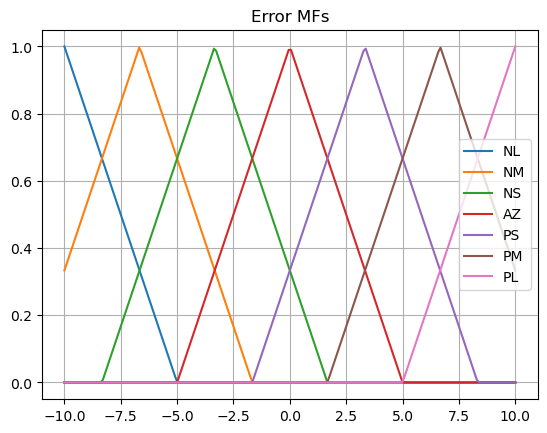

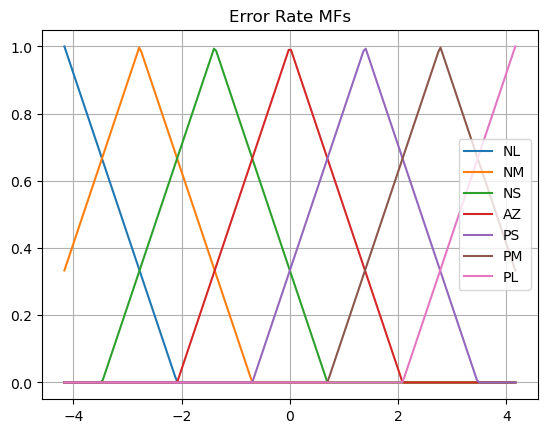

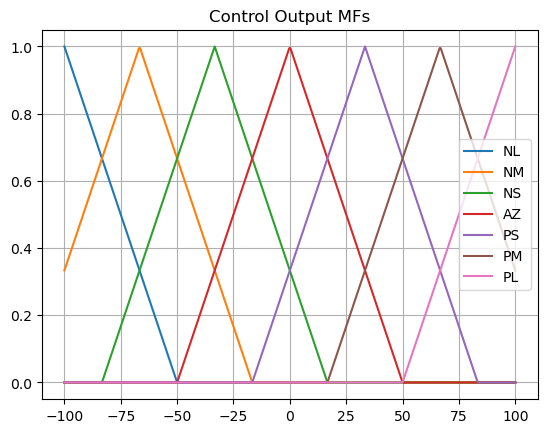

In [9]:
# ---------- Plot input/output MFs ----------
def plot_mfs(x, mfs, title):
    plt.figure()
    for k, v in mfs.items():
        plt.plot(x, v, label=k)
    plt.title(title)
    plt.legend()
    plt.grid(True)

plot_mfs(e, E_mfs, "Error MFs")
plot_mfs(edot, Edot_mfs, "Error Rate MFs")
plot_mfs(u, U_mfs, "Control Output MFs")


In [10]:
rules = [
    ("NS","NS","NS"),
    ("NS","AZ","NS"),
    ("AZ","NS","AZ"),
    ("AZ","AZ","AZ"),
    ("AZ","PS","AZ"),
    ("PS","AZ","PS"),
    ("PS","PS","PS"),
]

In [11]:
# ---------- Mamdani Inference ----------
def fuzzy_inference(e_val, edot_val):
    # Compute membership values
    e_vals = {k: triangular(e_val, -10 + i*20/6 - 20/12, -10 + i*20/6, -10 + i*20/6 + 20/12) for i,k in enumerate(labels)}
    edot_vals = {k: triangular(edot_val, -5/1.2 + i*(10/1.2)/6 - (10/1.2)/12,
                               -5/1.2 + i*(10/1.2)/6,
                               -5/1.2 + i*(10/1.2)/6 + (10/1.2)/12) for i,k in enumerate(labels)}

    aggregated = np.zeros_like(u)

    for rule in rules:
        e_set, edot_set, u_set = rule
        firing_strength = min(e_vals[e_set], edot_vals[edot_set])  # AND=min
        clipped = np.fmin(firing_strength, U_mfs[u_set])           # Implication (clip)
        aggregated = np.fmax(aggregated, clipped)                  # Aggregation (max)

    # Defuzzification: centroid
    u_star = np.sum(u * aggregated) / np.sum(aggregated) if np.sum(aggregated) != 0 else 0
    return u_star, aggregated

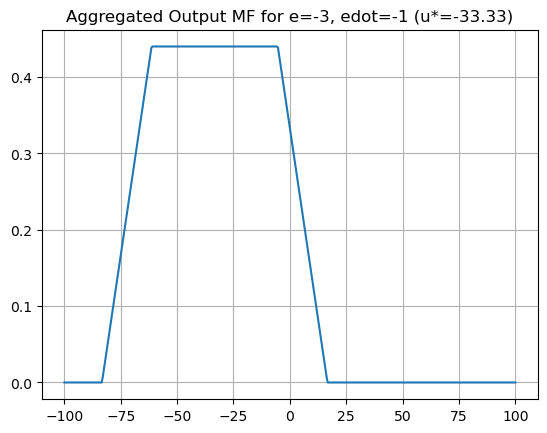

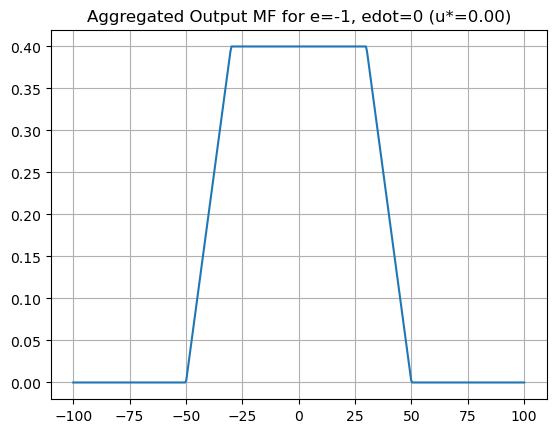

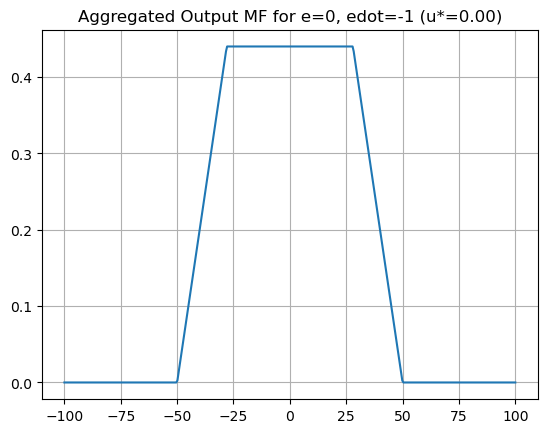

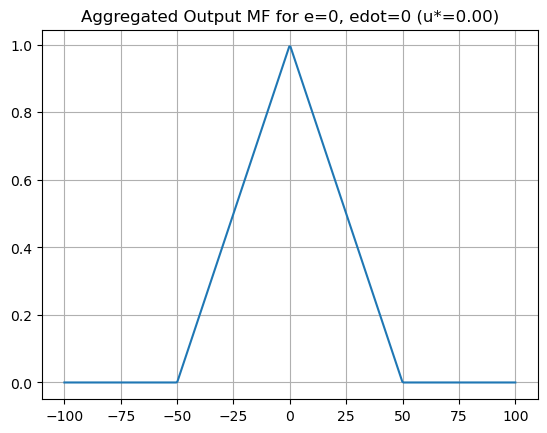

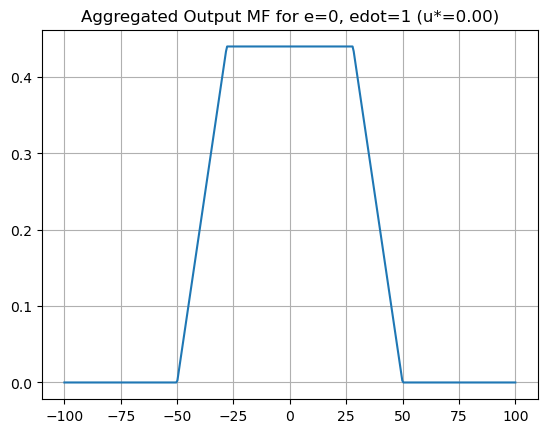

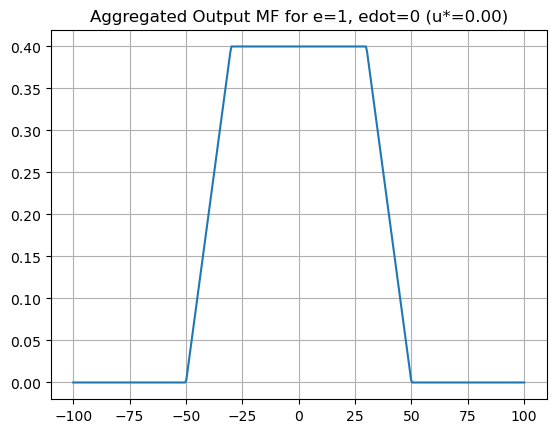

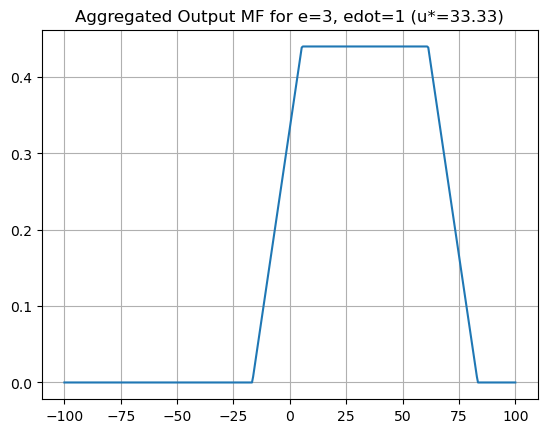

Input (e,ė)=(-3, -1) -> Output u*=-33.33
Input (e,ė)=(-1, 0) -> Output u*=0.00
Input (e,ė)=(0, -1) -> Output u*=0.00
Input (e,ė)=(0, 0) -> Output u*=0.00
Input (e,ė)=(0, 1) -> Output u*=0.00
Input (e,ė)=(1, 0) -> Output u*=0.00
Input (e,ė)=(3, 1) -> Output u*=33.33


In [12]:
# ---------- Test pairs ----------
test_pairs = [(-3,-1), (-1,0), (0,-1), (0,0), (0,1), (1,0), (3,1)]
results = {}

for pair in test_pairs:
    u_star, agg = fuzzy_inference(pair[0], pair[1])
    results[pair] = u_star
    plt.figure()
    plt.plot(u, agg)
    plt.title(f"Aggregated Output MF for e={pair[0]}, edot={pair[1]} (u*={u_star:.2f})")
    plt.grid(True)

plt.show()

# Print crisp outputs
for k,v in results.items():
    print(f"Input (e,ė)={k} -> Output u*={v:.2f}")

In [17]:
#------------------------- Task 1 clustering-------------------

In [2]:

import pandas as pd



# Load data
data = pd.read_csv('Mine_Dataset.csv')
print(data.head())  # Show first 5 rows


          V         H    S  M
0  0.338157  0.000000  0.0  1
1  0.320241  0.181818  0.0  1
2  0.287009  0.272727  0.0  1
3  0.256284  0.454545  0.0  1
4  0.262840  0.545455  0.0  1


In [3]:
import numpy as np
import matplotlib.pyplot as plt

class FuzzyCMeans:
    def __init__(self, c=2, m=2.0, epsilon=1e-4, max_iter=300):
        self.c = c
        self.m = m
        self.epsilon = epsilon
        self.max_iter = max_iter
    
    def initialize_U(self, n_samples):
        U = np.random.rand(n_samples, self.c)
        U = U / np.sum(U, axis=1, keepdims=True)
        return U

    def compute_centers(self, X, U):
        um = U ** self.m
        centers = (um.T @ X) / np.sum(um.T, axis=1, keepdims=True)
        return centers

    def update_U(self, X, centers):
        dist = np.linalg.norm(X[:, np.newaxis] - centers, axis=2) + 1e-10
        power = 2 / (self.m - 1)
        denominator = (dist[:, :, np.newaxis] / dist[:, np.newaxis, :]) ** power
        U = 1 / np.sum(denominator, axis=2)
        return U

    def compute_Jm(self, X, centers, U):
        dist = np.linalg.norm(X[:, np.newaxis] - centers, axis=2)
        Jm = np.sum((U ** self.m) * (dist ** 2))
        return Jm

    def fit(self, X):
        n_samples = X.shape[0]
        U = self.initialize_U(n_samples)
        Jm_history = []
        centers_history = []
        
        for iteration in range(self.max_iter):
            centers = self.compute_centers(X, U)
            centers_history.append(centers)
            U_new = self.update_U(X, centers)
            Jm = self.compute_Jm(X, centers, U_new)
            Jm_history.append(Jm)
            
            if np.linalg.norm(U_new - U) < self.epsilon:
                break
            U = U_new
        
        self.centers = centers
        self.U = U
        self.Jm_history = Jm_history
        self.centers_history = centers_history
        self.iterations = iteration + 1
        return self


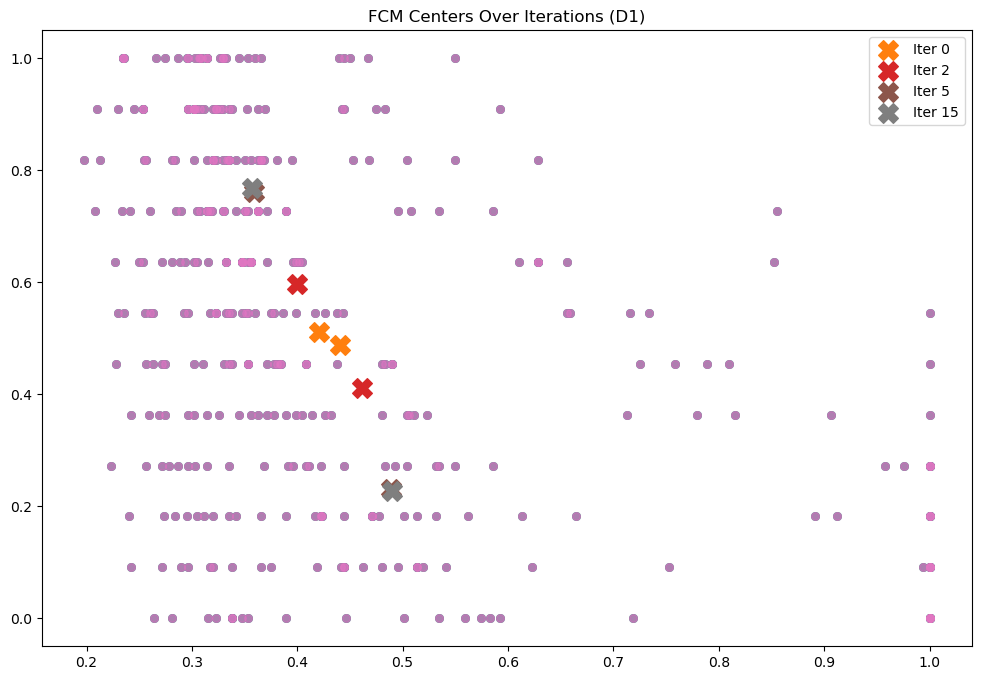

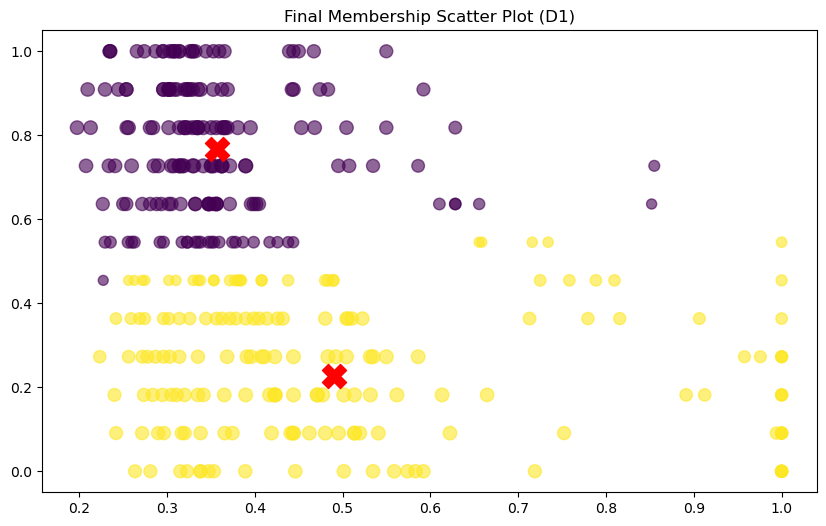

Top-5 most ambiguous points (lowest max membership):
[[0.25628362 0.45454545]
 [0.2628396  0.45454545]
 [0.22752244 0.45454545]
 [0.27190303 0.45454545]
 [0.27492417 0.45454545]]
Final Jm: 14.6861
Iterations to converge: 16


In [5]:
# Prepare data
X = data.values[:, :2]  # Assuming first two columns are features

# Train FCM
fcm = FuzzyCMeans(c=2)
fcm.fit(X)

# Plot Centers Over Iterations
plt.figure(figsize=(12, 8))
for i, centers in enumerate(fcm.centers_history):
    if i in [0, 2, 5, fcm.iterations-1]:
        plt.scatter(X[:, 0], X[:, 1], s=30, alpha=0.5)
        plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200, label=f'Iter {i}')
plt.legend()
plt.title('FCM Centers Over Iterations (D1)')
plt.show()

# Final Membership Scatter Plot
hard_labels = np.argmax(fcm.U, axis=1)
max_membership = np.max(fcm.U, axis=1)

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=hard_labels, s=100 * max_membership, alpha=0.6)
plt.scatter(fcm.centers[:, 0], fcm.centers[:, 1], marker='X', s=300, c='red')
plt.title('Final Membership Scatter Plot (D1)')
plt.show()

# Top-5 Most Ambiguous Points
ambiguity = np.max(fcm.U, axis=1)
ambiguous_indices = np.argsort(ambiguity)[:5]
print("Top-5 most ambiguous points (lowest max membership):")
print(X[ambiguous_indices])

# Final Jm and Iterations to Converge
print(f'Final Jm: {fcm.Jm_history[-1]:.4f}')
print(f'Iterations to converge: {fcm.iterations}')



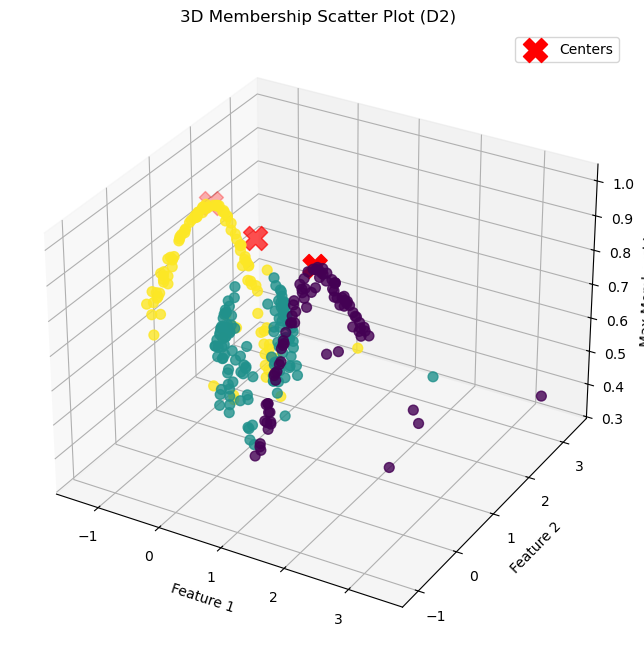

In [7]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# Final hard labels and max membership
hard_labels = np.argmax(fcm2.U, axis=1)
max_membership = np.max(fcm2.U, axis=1)

# 3D Scatter Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_d2[:, 0], 
    X_d2[:, 1], 
    max_membership,  # Z axis
    c=hard_labels, 
    s=50, 
    alpha=0.8,
    cmap='viridis'
)

# Plot cluster centers (flat max_membership = 1)
ax.scatter(
    fcm2.centers[:, 0], 
    fcm2.centers[:, 1], 
    [1]*fcm2.centers.shape[0], 
    marker='X', 
    s=300, 
    c='red', 
    label='Centers'
)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Max Membership')
ax.set_title('3D Membership Scatter Plot (D2)')

plt.legend()
plt.show()


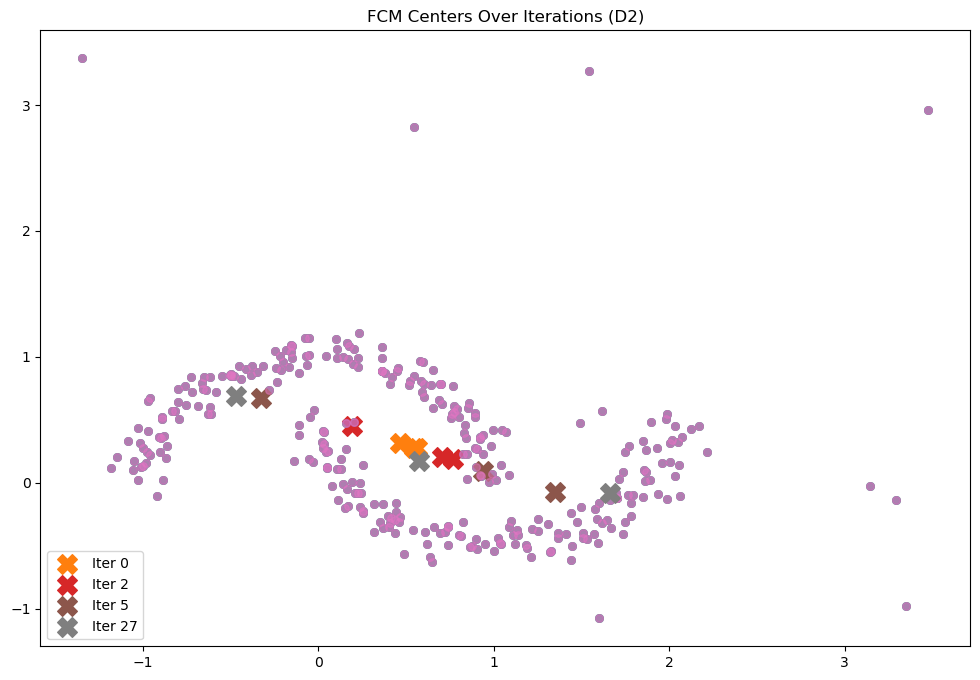

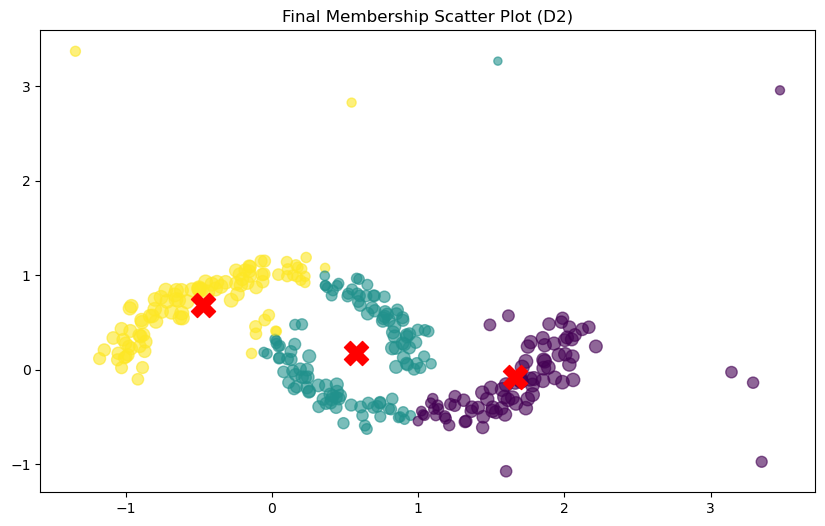

Final Jm: 78.2606
Iterations to converge: 28
Observation: FCM struggles in the 'bridge' region where moons overlap, leading to ambiguous memberships.


In [6]:
from sklearn.datasets import make_moons

# Generate data
X_moons, _ = make_moons(n_samples=300, noise=0.08, random_state=42)
outliers = np.random.uniform(-1.5, 3.5, size=(10, 2))
X_d2 = np.vstack((X_moons, outliers))

# Train FCM
fcm2 = FuzzyCMeans(c=3)
fcm2.fit(X_d2)

# Plot Centers Over Iterations
plt.figure(figsize=(12, 8))
for i, centers in enumerate(fcm2.centers_history):
    if i in [0, 2, 5, fcm2.iterations-1]:
        plt.scatter(X_d2[:, 0], X_d2[:, 1], s=30, alpha=0.5)
        plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200, label=f'Iter {i}')
plt.legend()
plt.title('FCM Centers Over Iterations (D2)')
plt.show()

# Final Membership Scatter Plot
hard_labels = np.argmax(fcm2.U, axis=1)
max_membership = np.max(fcm2.U, axis=1)

plt.figure(figsize=(10, 6))
plt.scatter(X_d2[:, 0], X_d2[:, 1], c=hard_labels, s=100 * max_membership, alpha=0.6)
plt.scatter(fcm2.centers[:, 0], fcm2.centers[:, 1], marker='X', s=300, c='red')
plt.title('Final Membership Scatter Plot (D2)')
plt.show()

# Final Jm and Iterations to Converge
print(f'Final Jm: {fcm2.Jm_history[-1]:.4f}')
print(f'Iterations to converge: {fcm2.iterations}')

# Observation
print("Observation: FCM struggles in the 'bridge' region where moons overlap, leading to ambiguous memberships.")


In [13]:
#----------------Task-2 Clustering------------

In [17]:
import pandas as pd

# Load dataset
data = pd.read_csv('Mine_Dataset.csv')
X = data.values

m_values = [1.25, 1.5, 2.0, 3.0]
results = []

for m in m_values:
    fcm = FuzzyCMeans(c=3, m=m, epsilon=1e-5, max_iter=300)
    fcm.fit(X)
    
    U = fcm.U
    n_samples = X.shape[0]
    
    # Partition Coefficient (PC)
    PC = np.sum(U ** 2) / n_samples
    
    # Classification Entropy (CE)
    CE = -np.sum(U * np.log(np.fmax(U, 1e-10))) / n_samples
    
    results.append({
        'm': m,
        'iterations': fcm.iterations,
        'Jm': fcm.Jm_history[-1],
        'PC': PC,
        'CE': CE
    })
    
    print(f"m={m}: iterations={fcm.iterations}, Jm={fcm.Jm_history[-1]:.4f}, PC={PC:.4f}, CE={CE:.4f}")

# Convert to DataFrame for easier handling and plotting
results_df = pd.DataFrame(results)


m=1.25: iterations=13, Jm=150.2582, PC=0.9779, CE=0.0510
m=1.5: iterations=75, Jm=143.5588, PC=0.8638, CE=0.2424
m=2.0: iterations=66, Jm=112.0748, PC=0.6855, CE=0.5573
m=3.0: iterations=28, Jm=50.0852, PC=0.4874, CE=0.8746


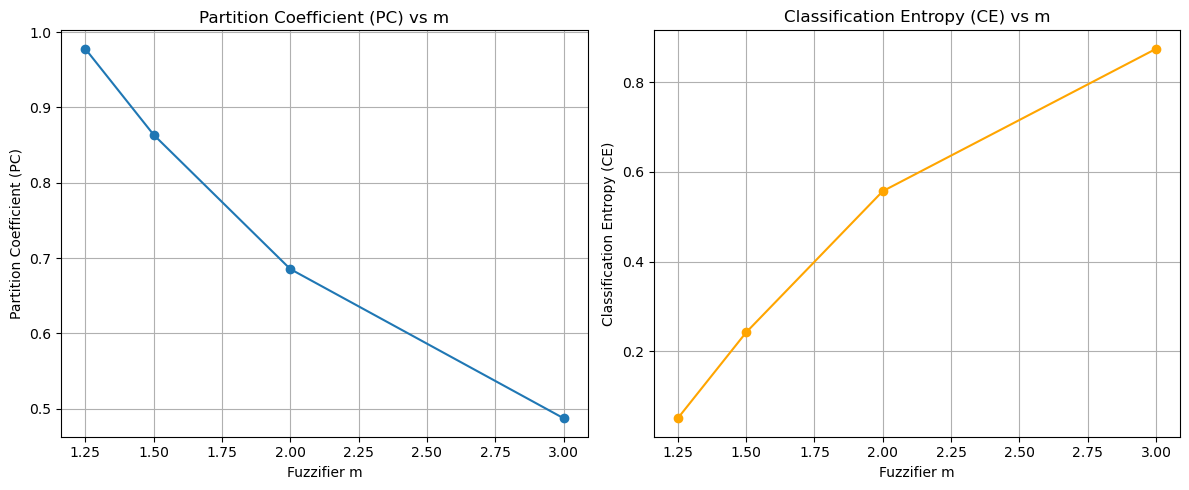

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Partition Coefficient Plot
plt.subplot(1, 2, 1)
plt.plot(results_df['m'], results_df['PC'], marker='o')
plt.title('Partition Coefficient (PC) vs m')
plt.xlabel('Fuzzifier m')
plt.ylabel('Partition Coefficient (PC)')
plt.grid(True)

# Classification Entropy Plot
plt.subplot(1, 2, 2)
plt.plot(results_df['m'], results_df['CE'], marker='o', color='orange')
plt.title('Classification Entropy (CE) vs m')
plt.xlabel('Fuzzifier m')
plt.ylabel('Classification Entropy (CE)')
plt.grid(True)

plt.tight_layout()
plt.show()


In [19]:
#As the fuzzifier m increases, the partition coefficient (PC) decreases and classification entropy (CE) increases. Smaller m values lead to crisper memberships where data points are strongly assigned to a particular cluster, resulting in faster convergence and lower CE. Larger m values blur the assignments, increasing fuzziness, making convergence slower, and leading to a higher CE as memberships spread more uniformly. This trade-off impacts stability and cluster interpretability.

In [23]:
#--------------------Task 3 Clustering--------------------

In [20]:
from sklearn.cluster import KMeans

# Run k-means with k=2 and 10 random restarts
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X)


In [21]:
from scipy.optimize import linear_sum_assignment

# Assuming last FCM run used m=2.0 (adjust if needed)
fcm = FuzzyCMeans(c=2, m=2.0, epsilon=1e-5, max_iter=300)
fcm.fit(X)
U = fcm.U

# Convert FCM membership to crisp labels by argmax
fcm_labels = np.argmax(U, axis=1)

# Align cluster IDs using Hungarian matching
cost_matrix = np.zeros((2, 2))
for i in range(2):
    for j in range(2):
        cost_matrix[i, j] = np.sum((fcm_labels == i) != (kmeans_labels == j))

row_ind, col_ind = linear_sum_assignment(cost_matrix)

# Map FCM labels to aligned KMeans labels
aligned_fcm_labels = np.zeros_like(fcm_labels)
for i, j in zip(row_ind, col_ind):
    aligned_fcm_labels[fcm_labels == i] = j

# Compute mis-match rate
mismatch_rate = np.mean(aligned_fcm_labels != kmeans_labels)
print(f"Mis-match rate between FCM and k-means labels: {mismatch_rate:.4f}")


Mis-match rate between FCM and k-means labels: 0.0000


In [22]:
# Calculate the difference between top two memberships for all points
membership_diff = np.abs(U[:, 0] - U[:, 1])

# Pick 3 points with membership difference closest to 0.5 (most borderline)
borderline_indices = np.argsort(np.abs(membership_diff - 0.5))[:3]

print("\nThree borderline example points and their FCM membership vectors:")
for idx in borderline_indices:
    print(f"Point index: {idx}")
    print(f"Data: {X[idx]}")
    print(f"FCM Membership Vector: {U[idx]}")
    print(f"K-means Label: {kmeans_labels[idx]}, FCM Crisp Label: {aligned_fcm_labels[idx]}")
    print("-" * 60)



Three borderline example points and their FCM membership vectors:
Point index: 86
Data: [0.99999873 0.         1.         2.        ]
FCM Membership Vector: [0.87574772 0.12425228]
K-means Label: 1, FCM Crisp Label: 1
------------------------------------------------------------
Point index: 47
Data: [0.99999873 0.         0.         2.        ]
FCM Membership Vector: [0.87600417 0.12399583]
K-means Label: 1, FCM Crisp Label: 1
------------------------------------------------------------
Point index: 48
Data: [0.99999873 0.09090909 0.         2.        ]
FCM Membership Vector: [0.88497983 0.11502017]
K-means Label: 1, FCM Crisp Label: 1
------------------------------------------------------------
